# 4.0 Modeling

Este notebook desarrolla la fase de modelado de CRISP_DM, utilizando el dataset ya preparado de la fase anterior para construir diferentes modelos de clusterización. Esto, con el de lograr llegar a entender mejor la **resiliencia académica** (bajo INSE con percentiles sobresalientes).

Debido a que no se trabajará con una variable objetivo, los modelos que se desarrollan en este notebook son técnicas de clusterización y no modelos predictivos supervisados.

### Sobre las columnas de puntaje y desempeño por módulo

Conviene retirar las columnas `mod_*_punt`, `mod_*_desem`, `mod_*_pnal` y `mod_*_pnbc` para la clusterización de estudiantes, ya que `punt_global` y `percentil_global` se calculan a partir de ellas, de lo contrario habría multicolinealidad.

## 1. Carga de los datos preparados

In [91]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

In [92]:
RANDOM_STATE = 42

# Las rutas funcionan desde la raíz del proyecto o desde notebooks/
if Path('data/processed/Examen_Saber_Pro_Genericas_2024_limpio.csv').exists():
    project_root = Path.cwd()
else:
    project_root = Path.cwd().parent

input_path = project_root / 'data/processed/Examen_Saber_Pro_Genericas_2024_limpio.csv'
output_students_path = project_root / 'data/processed/saber_pro_2024_clusters_estudiantes.csv'

df = pd.read_csv(input_path, encoding='utf-8-sig', low_memory=False)

print(f'Dataset preparado: {df.shape[0]:,} filas x {df.shape[1]} columnas')
display(df.head())

Dataset preparado: 259,703 filas x 95 columnas


,periodo,estu_consecutivo,estu_estudiante,estu_tipodocumento,estu_nacionalidad,estu_actividadrefuerzoareas,estu_actividadrefuerzogeneric,estu_agregado,estu_cod_depto_presentacion,estu_cod_mcpio_presentacion,...,mod_razona_cuantitativo_pnal,mod_razona_cuantitativo_pnbc,percentil_global,percentil_nbc,punt_global,estado_vinculacion_ies,estado_percentil_nbc,estado_contexto_socioeconomico,estado_resultado_ingles,estado_comunicacion_escrita
0,20241,EK202410108477,ESTUDIANTE,CC,COLOMBIA,NO INFORMADO - BLOQUE NO DILIGENCIADO,NO INFORMADO - BLOQUE NO DILIGENCIADO,S,5,5001,...,100,100.0,98.0,96.0,194,VINCULADO A IES,DISPONIBLE,DISPONIBLE,DISPONIBLE,DISPONIBLE
1,20241,EK202410075644,ESTUDIANTE,CC,COLOMBIA,NO INFORMADO - BLOQUE NO DILIGENCIADO,NO INFORMADO - BLOQUE NO DILIGENCIADO,S,11,11001,...,82,94.0,89.0,93.0,176,VINCULADO A IES,DISPONIBLE,DISPONIBLE,DISPONIBLE,DISPONIBLE
2,20241,EK202410088553,ESTUDIANTE,CC,COLOMBIA,NO INFORMADO - BLOQUE NO DILIGENCIADO,NO INFORMADO - BLOQUE NO DILIGENCIADO,S,5,5001,...,96,81.0,56.0,33.0,149,VINCULADO A IES,DISPONIBLE,DISPONIBLE,DISPONIBLE,DISPONIBLE
3,20241,EK202410022739,ESTUDIANTE,CC,COLOMBIA,NO INFORMADO - BLOQUE NO DILIGENCIADO,NO INFORMADO - BLOQUE NO DILIGENCIADO,S,11,11001,...,60,67.0,55.0,52.0,149,VINCULADO A IES,DISPONIBLE,DISPONIBLE,DISPONIBLE,DISPONIBLE
4,20241,EK202410117700,ESTUDIANTE,CC,COLOMBIA,NO INFORMADO - BLOQUE NO DILIGENCIADO,NO INFORMADO - BLOQUE NO DILIGENCIADO,N,11,11001,...,69,78.0,56.0,62.0,150,VINCULADO A IES,DISPONIBLE,DISPONIBLE,DISPONIBLE,DISPONIBLE


## 2. Selección de variables relevantes

Agrupación de las columnas según su papel en el análisis, siguiendo el diccionario construido en `1_0-business-understanding.ipynb`:

- **Entorno del hogar**
- **Trayectoria previa**
- **Desempeño**
- **Contexto institucional / geográfico** (aunque estas no entran en el modelo porque la idea es evaluar el perfil del estudiante y no de la institución)
- **Identificadores / llaves** (se excluyen del modelo)

In [93]:
# Variables ordinales del hogar
household_ordinal_cols = [
    'fami_estratovivienda',
    'fami_educacionmadre',
    'fami_educacionpadre',
]

# Variables binarias del hogar
household_binary_cols = [
    'fami_tieneautomovil', 'fami_tienecomputador',
    'fami_tienehornomicroogas', 'fami_tieneinternet', 'fami_tienelavadora',
    'fami_tienemotocicleta', 'fami_tieneserviciotv',
]

# Variables nominales del hogar
household_nominal_cols = [
    'fami_ocupacionmadre', 'fami_ocupacionpadre',
    'fami_trabajolabormadre', 'fami_trabajolaborpadre',
]

# Índice socioeconómico individual
household_numeric_cols = ['estu_inse_individual']

# Trayectoria previa
trajectory_cols = [
    'estu_tituloobtenidobachiller', 'estu_actividadrefuerzogeneric',
    'estu_actividadrefuerzoareas', 'estu_cursoiesexterna',
    'estu_cursoiesapoyoexterno', 'estu_cursodocentesies',
    'estu_simulacrotipoicfes',
]

# Desempeño
performance_col = 'punt_global'
performance_reference_col = 'percentil_global'

# Variables contexto institucional y geográfico
profiling_cols = [
    'estu_metodo_prgm', 'estu_nivel_prgm_academico', 'estu_nucleo_pregrado',
    'inst_caracter_academico', 'inst_origen', 'estu_prgm_departamento',
    'estu_prgm_academico', 'estu_snies_prgmacademico',
]

# Explícitamente excluidas: columnas de puntaje/desempeño por módulo, identificadores, y columnas de estado auxiliares de la preparación
excluded_cols = [c for c in df.columns if c.startswith('mod_')] + [
    'estu_consecutivo', 'periodo', 'estado_vinculacion_ies', 'estado_percentil_nbc',
    'estado_contexto_socioeconomico', 'estado_resultado_ingles', 'estado_comunicacion_escrita',
]

print('Columnas excluidas explícitamente:', len(excluded_cols))
print(excluded_cols)

Columnas excluidas explícitamente: 27
['mod_competen_ciudada_desem', 'mod_competen_ciudada_pnal', 'mod_competen_ciudada_pnbc', 'mod_competen_ciudada_punt', 'mod_comuni_escrita_desem', 'mod_comuni_escrita_pnal', 'mod_comuni_escrita_pnbc', 'mod_comuni_escrita_punt', 'mod_ingles_desem', 'mod_ingles_pnal', 'mod_ingles_pnbc', 'mod_ingles_punt', 'mod_lectura_critica_desem', 'mod_lectura_critica_pnal', 'mod_lectura_critica_pnbc', 'mod_lectura_critica_punt', 'mod_razona_cuantitat_desem', 'mod_razona_cuantitat_punt', 'mod_razona_cuantitativo_pnal', 'mod_razona_cuantitativo_pnbc', 'estu_consecutivo', 'periodo', 'estado_vinculacion_ies', 'estado_percentil_nbc', 'estado_contexto_socioeconomico', 'estado_resultado_ingles', 'estado_comunicacion_escrita']


## 3. Filtrado de registros válidos para la clusterización
Debido a que K_means y la clusterización jerárquica se basan en distancias, para este tipo de modelos, el valor centinela de -1 para indicar "no aplica", alteraría el resultado al tomarlo como un valor numérico más.

In [94]:
valid_mask = (
    df['estu_estudiante'].eq('ESTUDIANTE')
    & df['estado_contexto_socioeconomico'].eq('DISPONIBLE')
    & (df[performance_col] != -1)
    & (df[performance_reference_col] != -1)
)

print(f'Registros totales:            {len(df):,}')
print(f'Registros válidos para el modelo: {valid_mask.sum():,} ({valid_mask.mean()*100:.2f}%)')

df_model = df.loc[valid_mask].copy().reset_index(drop=True)


Registros totales:            259,703
Registros válidos para el modelo: 247,770 (95.41%)


## 4. Ingeniería de variables
### 4.1 Bienes del hogar
Se convierten las variables booleanas de `Si`/`No` a 0/1, y se crea `indice_bienes_hogar` que es el número de bienes que tiene el hogar, de 0 a 7.

In [95]:
for col in household_binary_cols:
    df_model[col] = df_model[col].map({'Si': 1, 'No': 0})

missing_after_map = df_model[household_binary_cols].isna().sum()
print('Valores no mapeados (deberían ser 0 si solo hay Si/No):')
print(missing_after_map[missing_after_map > 0])

df_model['indice_bienes_hogar'] = df_model[household_binary_cols].sum(axis=1)
display(df_model['indice_bienes_hogar'].describe().to_frame())


Valores no mapeados (deberían ser 0 si solo hay Si/No):
Series([], dtype: int64)


,indice_bienes_hogar
count,247770.000000
mean,4.477495
std,1.620854
min,0.000000
25%,3.000000
50%,5.000000
75%,6.000000
max,7.000000


### 4.2 Codificación de estrato y educación de los padres
`fami_estratovivienda`, `fami_educacionmadre` y `fami_educacionpadre` tienen un orden natural (a mayor estrato o nivel educativo, mayor "posición").

In [96]:
estrato_order = [
    'Sin estrato', 'Estrato 1', 'Estrato 2', 'Estrato 3',
    'Estrato 4', 'Estrato 5', 'Estrato 6',
]
estrato_map = {label: rank for rank, label in enumerate(estrato_order)}

educacion_order = [
    'Ninguno', 'No sabe', 'No Aplica',
    'Primaria incompleta', 'Primaria completa',
    'Secundaria (Bachillerato) incompleta', 'Secundaria (Bachillerato) completa',
    'Técnica o tecnológica incompleta', 'Técnica o tecnológica completa',
    'Educación profesional incompleta', 'Educación profesional completa',
    'Postgrado',
]
educacion_map = {label: rank for rank, label in enumerate(educacion_order)}
# 'No sabe' y 'No Aplica' se ubican junto a 'Ninguno': no aportan información de nivel educativo, así que no deberían "sumar" posiciones ordinales altas.
for etiqueta_neutra in ['No sabe', 'No Aplica']:
    educacion_map[etiqueta_neutra] = 0

ordinal_maps = {
    'fami_estratovivienda': estrato_map,
    'fami_educacionmadre': educacion_map,
    'fami_educacionpadre': educacion_map,
}

for col, mapping in ordinal_maps.items():
    categorias_presentes = set(df_model[col].dropna().unique())
    categorias_sin_mapa = categorias_presentes - set(mapping.keys())
    if categorias_sin_mapa:
        print(categorias_sin_mapa)
    df_model[col + '_ord'] = df_model[col].map(mapping)

df_model = df_model.dropna(subset=['fami_estratovivienda_ord']).copy()
household_ordinal_encoded_cols = [c + '_ord' for c in household_ordinal_cols]
faltantes_tras_ordinal = df_model[household_ordinal_encoded_cols].isna().sum()
print('\nFaltantes tras la codificación ordinal (deberían ser 0):')
print(faltantes_tras_ordinal)

{'Sin Estrato'}

Faltantes tras la codificación ordinal (deberían ser 0):
fami_estratovivienda_ord    0
fami_educacionmadre_ord     0
fami_educacionpadre_ord     0
dtype: int64


### 4.3 Codificación de variables nominales
Se convierten las variables que no tienen un orden en columnaas binarias independientes (One-Hot).

In [97]:
nominal_cols = household_nominal_cols + trajectory_cols

df_nominal_encoded = pd.get_dummies( # Esta función hace la separación automáticamente
    df_model[nominal_cols].astype('object'),
    prefix=nominal_cols,
    dummy_na=False,
)

print(f'Columnas nominales originales: {len(nominal_cols)}')
print(f'Columnas después de one-hot:   {df_nominal_encoded.shape[1]}')

Columnas nominales originales: 11
Columnas después de one-hot:   96


## 5. Lista variables y escalado
Se juntan las variables creadas y modificadas anteriormente en una sola lista y se normalizan lo valores para evitar problemas con el manejo de distancia.

In [98]:
feature_frames = [
    df_model[household_ordinal_encoded_cols].reset_index(drop=True),
    df_nominal_encoded.reset_index(drop=True),
    df_model[household_numeric_cols + [performance_col]].reset_index(drop=True),
]

X = pd.concat(feature_frames, axis=1)
feature_names = X.columns.tolist()

print(f'Matriz de variables: {X.shape[0]:,} filas x {X.shape[1]} columnas')
assert X.isna().sum().sum() == 0, 'No deberían quedar valores faltantes en X'

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Matriz de variables: 246,792 filas x 101 columnas


## 6. Reducción de dimensionalidad con PCA
Para resumir el conjunto de datos (si hay mucha correlación) en variables nuevas (componentes principales).

Componentes necesarios para explicar >= 85% de la varianza: 45


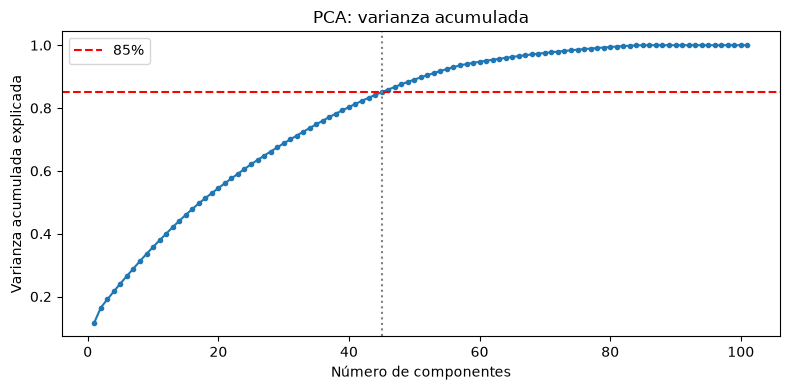

Espacio reducido para clusterizar: (246792, 45)


In [99]:
# PCA completo para decidir cuántos componentes conservar
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)
n_components_85 = int(np.argmax(varianza_acumulada >= 0.85) + 1)

print(f'Componentes necesarios para explicar >= 85% de la varianza: {n_components_85}')

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', markersize=3)
plt.axhline(0.85, color='red', linestyle='--', label='85%')
plt.axvline(n_components_85, color='gray', linestyle=':')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada explicada')
plt.title('PCA: varianza acumulada')
plt.legend()
plt.tight_layout()
plt.show()

# Espacio reducido que usaremos para clusterizar
pca_model = PCA(n_components=n_components_85, random_state=RANDOM_STATE)
X_pca = pca_model.fit_transform(X_scaled)

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f'Espacio reducido para clusterizar: {X_pca.shape}')

## 7. Selección del número de clústeres (k) para K-Means
Se utilizó el método del codo para seleccionar el número ideal de clusters.
**Método del codo**: suma de distancias al cuadrado de cada punto a su centroide (inercias) para varios `k`. Se busca el punto en donde el decrecimiento de las distancias ya no sea tan evidente.

k=2: inercia=18,280,203
k=3: inercia=17,507,742
k=4: inercia=17,082,574
k=5: inercia=16,587,321
k=6: inercia=16,225,105
k=7: inercia=15,798,377
k=8: inercia=15,333,900
k=9: inercia=15,082,676
k=10: inercia=14,569,932
k=11: inercia=14,274,528
k=12: inercia=13,993,945
k=13: inercia=13,584,459
k=14: inercia=13,227,584
k=15: inercia=12,769,251
k=16: inercia=12,563,437
k=17: inercia=12,299,804
k=18: inercia=12,055,418
k=19: inercia=11,927,178
El 'codo' matemático según el cambio de pendiente está en k = 15


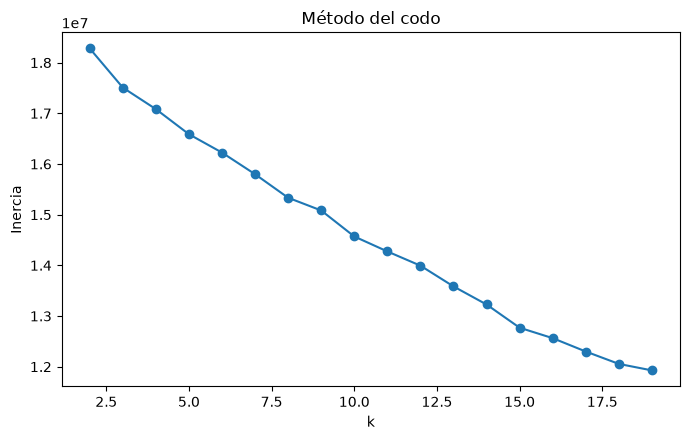

In [100]:
k_range = range(2, 20)
inertias = []

for k in k_range:
    kmeans_k = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    kmeans_k.fit(X_pca)
    inertias.append(kmeans_k.inertia_)
    print(f'k={k}: inercia={kmeans_k.inertia_:,.0f}')

    diffs = np.diff(inertias)
    diffs_ratio = diffs[:-1] / diffs[1:]

best_k_elbow = list(k_range)[np.argmax(diffs_ratio) + 1]
print(f"El 'codo' matemático según el cambio de pendiente está en k = {best_k_elbow}")
k_final = best_k_elbow

plt.figure(figsize=(7, 4.5))
plt.plot(list(k_range), inertias, marker='o')
plt.title('Método del codo')
plt.xlabel('k')
plt.ylabel('Inercia')
plt.tight_layout()
plt.show()

## 8. Entrenamiento del modelo final de K-Means

In [101]:
kmeans_final = KMeans(n_clusters=k_final, n_init=10, random_state=RANDOM_STATE)
df_model['cluster_kmeans'] = kmeans_final.fit_predict(X_pca)

print('Tamaño de cada clúster:')
display(df_model['cluster_kmeans'].value_counts().sort_index().to_frame('n_estudiantes'))

Tamaño de cada clúster:


,n_estudiantes
cluster_kmeans,
0,11432
1,24247
2,6480
3,26678
4,78436
5,5409
6,11826
7,11380
8,5361


## 9. Entrnamiento modelo DBSCAN
**DBSCAN** agrupa por densidad: une puntos que tienen suficientes vecinos cercanos, y marca como **ruido (etiqueta `-1`)** a los que quedan aislados. A diferencia de K-Means, no obliga a que todos los puntos pertenezcan a un clúster — por eso es una herramienta natural para la pregunta de **casos anómalos**: un estudiante de bajo INSE con un percentil global muy alto puede aparecer como "ruido" si su combinación de características es poco común frente al resto de la población.

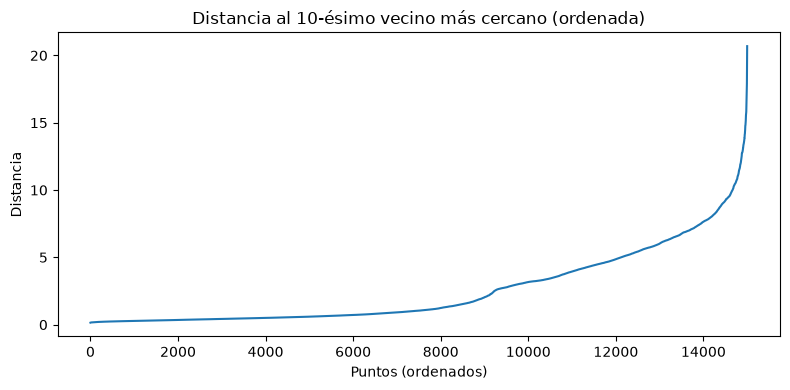

eps elegido: 8.214
Clústeres encontrados por DBSCAN: 20
Puntos marcados como ruido/atípicos: 472 (3.15% de la muestra)


In [102]:
dbscan_sample_size = min(15_000, X_pca.shape[0])
rng = np.random.default_rng(RANDOM_STATE)
dbscan_idx = rng.choice(X_pca.shape[0], size=dbscan_sample_size, replace=False)
X_dbscan_sample = X_pca[dbscan_idx]

min_samples = 10
neighbors = NearestNeighbors(n_neighbors=min_samples).fit(X_dbscan_sample)
distances, _ = neighbors.kneighbors(X_dbscan_sample)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.title(f'Distancia al {min_samples}-ésimo vecino más cercano (ordenada)')
plt.xlabel('Puntos (ordenados)')
plt.ylabel('Distancia')
plt.tight_layout()
plt.show()

eps_value = float(np.percentile(k_distances, 95))
print(f'eps elegido: {eps_value:.3f}')

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples)
labels_dbscan = dbscan.fit_predict(X_dbscan_sample)

n_noise = int((labels_dbscan == -1).sum())
n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
print(f'Clústeres encontrados por DBSCAN: {n_clusters_dbscan}')
print(f'Puntos marcados como ruido/atípicos: {n_noise:,} ({n_noise / dbscan_sample_size * 100:.2f}% de la muestra)')

df_model['cluster_dbscan'] = np.nan
df_model.iloc[dbscan_idx, df_model.columns.get_loc('cluster_dbscan')] = labels_dbscan

## 10. Bandera de "resiliencia académica"
Variable de referencia para interpretar los resultados de los clusters. La identificación se hizo filtrando a los estudiantes que estuvieran en el cuartil más bajo de INSE (bajo índice socioeconómico) y al mismo tiempo en el percentil global ≥ 90 (desempeño sobresaliente).

In [103]:
inse_q25 = df_model['estu_inse_individual'].quantile(0.25)
print(f'Percentil 25 de estu_inse_individual (umbral de "bajo INSE"): {inse_q25:.2f}')

df_model['resiliencia_flag'] = (
    (df_model['estu_inse_individual'] <= inse_q25)
    & (df_model[performance_reference_col] >= 90)
)

print('Estudiantes marcados como "resiliencia académica":')
display(df_model['resiliencia_flag'].value_counts().to_frame('n_estudiantes'))

Percentil 25 de estu_inse_individual (umbral de "bajo INSE"): 42.81
Estudiantes marcados como "resiliencia académica":


,n_estudiantes
resiliencia_flag,
False,244595
True,2197


## 11. Guardado de resultados para la fase de evaluación

In [104]:
pca_cols = [f'pca_{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pca_cols)
df_pca['pca_plot_1'] = X_pca_2d[:, 0]
df_pca['pca_plot_2'] = X_pca_2d[:, 1]

columns_to_export = (
    ['estu_consecutivo', 'cluster_kmeans', 'cluster_dbscan', 'resiliencia_flag',
     'punt_global', 'percentil_global', 'estu_inse_individual', 'indice_bienes_hogar']
    + household_ordinal_cols
    + profiling_cols
)

df_export = pd.concat(
    [df_model[columns_to_export].reset_index(drop=True), df_pca],
    axis=1,
)

output_students_path.parent.mkdir(parents=True, exist_ok=True)
df_export.to_csv(output_students_path, index=False, encoding='utf-8-sig')

print('Guardado:')
print(' -', output_students_path.resolve(), f'({len(df_export):,} filas)')

Guardado:
 - C:\Users\laura\Documents\Laura\Decimoprimero\colombia-higher-ed-assessment-analysis\data\processed\saber_pro_2024_clusters_estudiantes.csv (246,792 filas)


## 12. Resumen

- Se filtró la población a estudiantes vinculados a una IES con contexto socioeconómico y resultado global válidos.
- Se construyó una matriz de variables de **hogar + trayectoria + desempeño global** (sin puntajes por módulo, para evitar redundancia), se escaló y se redujo con PCA.
- Se entrenó **K-Means** con `k` elegido por silueta, se validó conceptualmente contra **clustering jerárquico** sobre una muestra, y se usó **DBSCAN** para señalar posibles casos atípicos.
- Se creó una bandera de negocio de "resiliencia académica" (no derivada del modelo) para usarla como referencia de interpretación.
- Todo se guardó en `data/processed/` para continuar en `5_0-evaluation.ipynb`.